# Exploratory Data Analysis (EDA) - [Titanic - Machine Learning from Disaster]

**Objective**: Predict passenger survival on the Titanic using machine learning through cleaning, and feature analysis, and model training

**Data Source**: [Kaggle: Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

## Packages installation and libraries importation

In [102]:
pip install pandas numpy matplotlib torch scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [103]:
# Some common libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data

In [104]:
df = pd.read_csv('data/train.csv')
print(f"Initial dataset shape: {df.shape}")
print(df.shape)
df.head()

Initial dataset shape: (891, 12)
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data overview

In [105]:
print("Data info:")
df.info()
df.describe()
print("\nMissing values per column:")
print(df.isna().sum())

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          

## Data encoding

In [106]:
df.drop(['PassengerId'], axis=1, inplace=True)
df = pd.get_dummies(df, columns=['Sex'], dtype=int)
df

,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_female,Sex_male
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,1,0
4,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,S,0,1
887,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,S,1,0
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.4500,NaN,S,1,0
889,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,C,0,1


## Univariate Analysis

In [107]:
features = df.columns
print("Availabel features:")
features = features.drop(['Name', 'Ticket', 'Cabin'])
features

Availabel features:


Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Sex_female', 'Sex_male'],
      dtype='object')

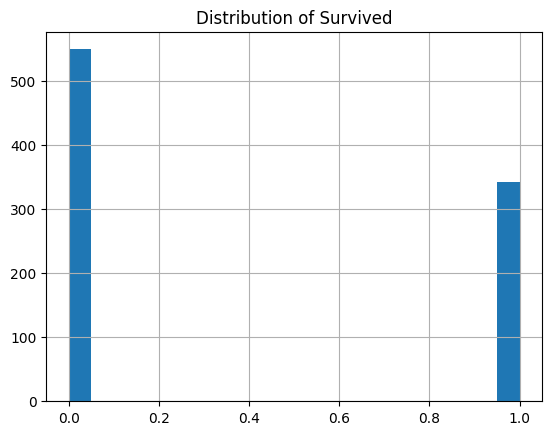

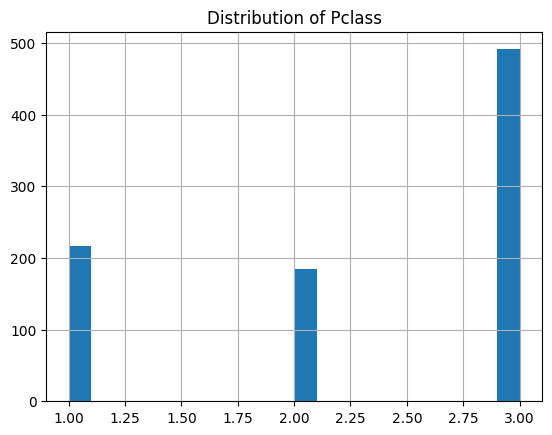

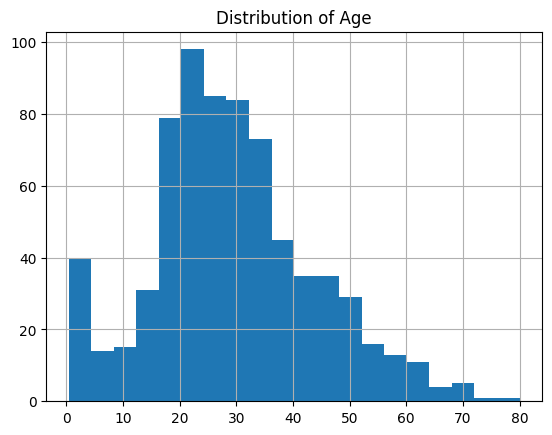

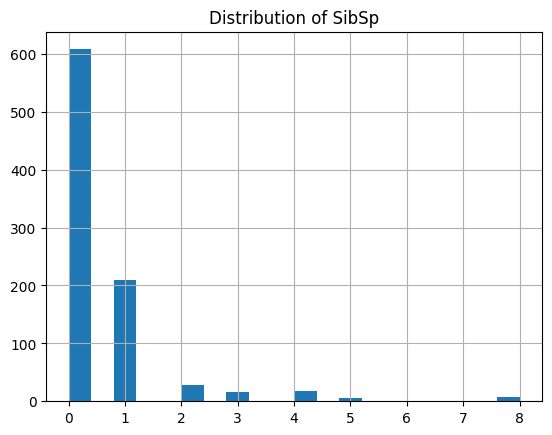

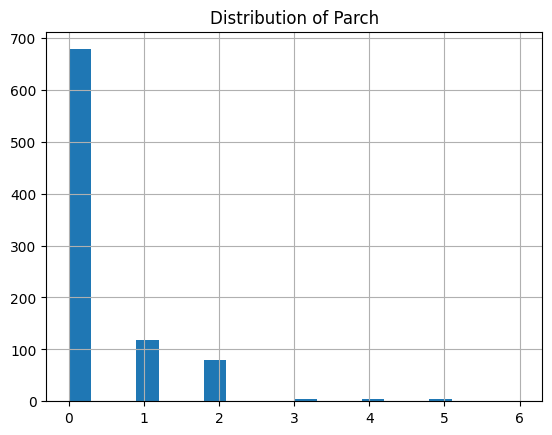

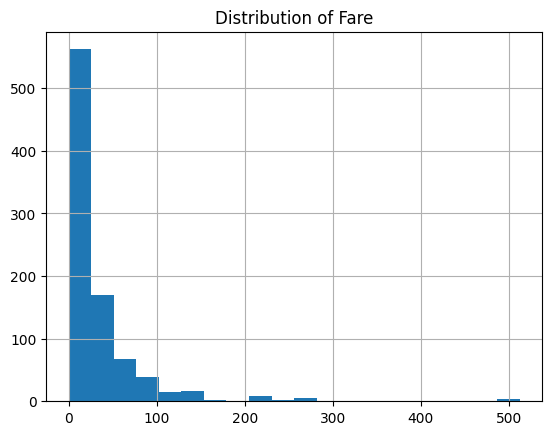

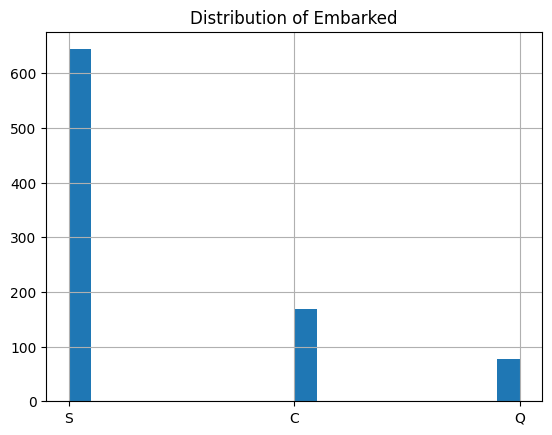

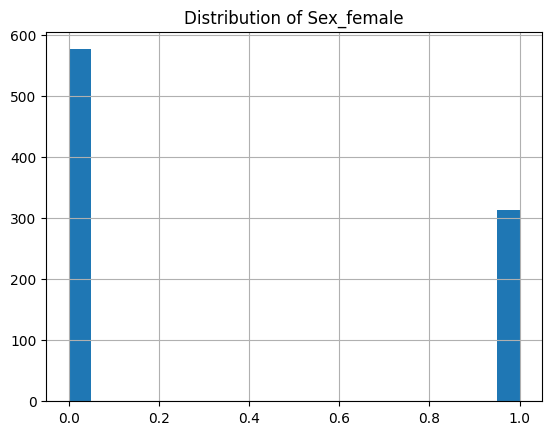

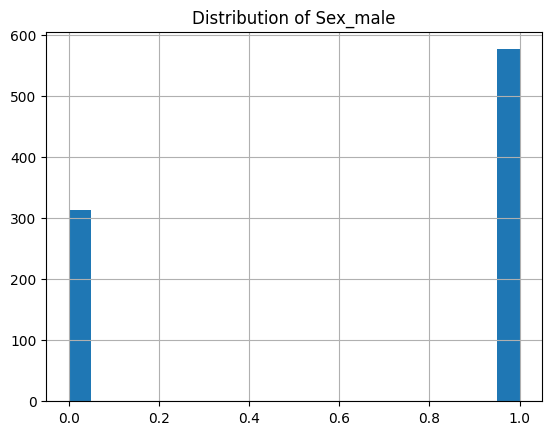

In [108]:
for fea in features:
    df[fea].hist(bins=20)
    plt.title(f'Distribution of {fea}')
    plt.show()

In [109]:
# Keep only numeric columns (required for correlation)
numeric_df = df.select_dtypes(include=['number'])


## Bivariate/Multivariate Analysis

In [ ]:
corr_matrix = numeric_df.corr()

# View correlation of all features with 'Survived'
print(corr_matrix['Survived'].sort_values(ascending=False))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

## Handle Missing Values & Outliers

## Feature Engineering

In [112]:
# Encoding the fields to numerical values

def reformat_name(name):
    if ',' in name or '.' in name:
        title = name.split(', ')[1].split('. ')[0].strip()
        return f"{title}"
    return name
    
def reformat_sex(sex):
    return 1 if sex =='male' else 0

def reformat_embark(embark):
    if embark == 'S':
        return 0
    elif embark == 'C':
        return 1
    elif embark == 'Q':
        return 2
    
df['Name'] = df['Name'].apply(reformat_name)
df['Sex'] = df['Sex'].apply(reformat_sex)
df['Embarked'] = df['Embarked'].apply(reformat_embark)

KeyError: 'Sex'

In [ ]:
for col in df.columns:
    num_unique_values = df[col].nunique()
    if num_unique_values / len(df) > 0.5:
        print(f"Column '{col}' has high cardinality with {num_unique_values} unique values over {len(df)} data.")

Column 'PassengerId' has high cardinality with 891 unique values over 891 data.
Column 'Ticket' has high cardinality with 681 unique values over 891 data.


In [ ]:
IGNORED_COLUMNS = ['PassengerId', 'Ticket', 'Cabin']

df.drop(columns=IGNORED_COLUMNS, inplace=True, axis=1)
print(f"\nTruncated dataset shape: {df.shape}")
display(df.head(n=10))


Truncated dataset shape: (891, 9)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,Mr,1,22.0,1,0,7.2500,0.0
1,1,1,Mrs,0,38.0,1,0,71.2833,1.0
2,1,3,Miss,0,26.0,0,0,7.9250,0.0
3,1,1,Mrs,0,35.0,1,0,53.1000,0.0
4,0,3,Mr,1,35.0,0,0,8.0500,0.0
5,0,3,Mr,1,NaN,0,0,8.4583,2.0
6,0,1,Mr,1,54.0,0,0,51.8625,0.0
7,0,3,Master,1,2.0,3,1,21.0750,0.0
8,1,3,Mrs,0,27.0,0,2,11.1333,0.0
9,1,2,Mrs,0,14.0,1,0,30.0708,1.0


In [ ]:
# Filled dataset
for col in df.select_dtypes(include=[np.number]).columns:
    skewness = df[col].skew()
    print(f"{col} → skewness: {skewness:.2f}")
    
    if abs(skewness) < 0.5:
        fill_value = df[col].mean()
        method = "mean"
    else:
        fill_value = df[col].median()
        method = "median"
    if df[col].isnull().sum() > 0:
        df.fillna({col: fill_value}, inplace=True)
        print(f"Filled {col} using {method} ({fill_value:.2f})")

Survived → skewness: 0.48
Pclass → skewness: -0.63
Sex → skewness: -0.62
Age → skewness: 0.39
Filled Age using mean (29.70)
SibSp → skewness: 3.70
Parch → skewness: 2.75
Fare → skewness: 4.79
Embarked → skewness: 1.54
Filled Embarked using median (0.00)


In [ ]:
df_encoded = pd.get_dummies(df, columns=['Pclass', 'Name', 'Sex', 'Embarked'], dtype=int, drop_first=True)
df_encoded

,Survived,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Name_Col,Name_Don,Name_Dr,...,Name_Mme,Name_Mr,Name_Mrs,Name_Ms,Name_Rev,Name_Sir,Name_the Countess,Sex_1,Embarked_1.0,Embarked_2.0
0,0,22.000000,1,0,7.2500,0,1,0,0,0,...,0,1,0,0,0,0,0,1,0,0
1,1,38.000000,1,0,71.2833,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,1,26.000000,0,0,7.9250,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,35.000000,1,0,53.1000,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,35.000000,0,0,8.0500,0,1,0,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,27.000000,0,0,13.0000,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
887,1,19.000000,0,0,30.0000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
888,0,29.699118,1,2,23.4500,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
889,1,26.000000,0,0,30.0000,0,0,0,0,0,...,0,1,0,0,0,0,0,1,1,0


In [ ]:
for col in df.columns:
    if col == 'Survived':
        continue
    for unique_value in df[col].unique():
        if pd.isna(unique_value):
            continue
        count = df.loc[df[col] == unique_value]["Survived"]
        print(f"% of {col} {unique_value} who survived:", sum(count)/len(count))
    print("-----\n")

% of Pclass 3 who survived: 0.24236252545824846
% of Pclass 1 who survived: 0.6296296296296297
% of Pclass 2 who survived: 0.47282608695652173
-----

% of Name Mr who survived: 0.15667311411992263
% of Name Mrs who survived: 0.792
% of Name Miss who survived: 0.6978021978021978
% of Name Master who survived: 0.575
% of Name Don who survived: 0.0
% of Name Rev who survived: 0.0
% of Name Dr who survived: 0.42857142857142855
% of Name Mme who survived: 1.0
% of Name Ms who survived: 1.0
% of Name Major who survived: 0.5
% of Name Lady who survived: 1.0
% of Name Sir who survived: 1.0
% of Name Mlle who survived: 1.0
% of Name Col who survived: 0.5
% of Name Capt who survived: 0.0
% of Name the Countess who survived: 1.0
% of Name Jonkheer who survived: 0.0
-----

% of Sex 1 who survived: 0.18890814558058924
% of Sex 0 who survived: 0.7420382165605095
-----

% of Age 22.0 who survived: 0.4074074074074074
% of Age 38.0 who survived: 0.45454545454545453
% of Age 26.0 who survived: 0.3333333

## Key Insights & Summary

- Insight 1
- Insight 2
- Suggested next steps (e.g., modeling, deeper analysis)